In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!unzip interactions.zip

unzip:  cannot find or open interactions.zip, interactions.zip.zip or interactions.zip.ZIP.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM

In [14]:
# loading data
df = pd.read_csv('drive/MyDrive/data/interactions_train.csv')
print(df.shape)
print(df.describe())

(698901, 6)
            user_id      recipe_id         rating              u  \
count  6.989010e+05  698901.000000  698901.000000  698901.000000   
mean   1.247694e+07  156173.409849       4.574090    4249.330271   
std    1.525031e+08  126594.880211       0.959022    5522.602821   
min    1.533000e+03      38.000000       0.000000       0.000000   
25%    1.059880e+05   53169.000000       4.000000     455.000000   
50%    2.301020e+05  116484.000000       5.000000    1737.000000   
75%    4.801950e+05  234516.000000       5.000000    5919.000000   
max    2.002313e+09  537458.000000       5.000000   25075.000000   

                   i  
count  698901.000000  
mean    87519.330993  
std     51290.370370  
min         0.000000  
25%     42988.000000  
50%     87424.000000  
75%    131731.000000  
max    178262.000000  


In [15]:
# Create a new dataframe with two columns
df1 = df[['recipe_id', 'rating']].copy()
df1.head()

,recipe_id,rating
0,4684,5.0
1,517,5.0
2,7435,5.0
3,278,4.0
4,3431,5.0


In [16]:
df2 = df1.sample(10000, random_state=1).copy()

In [17]:
model = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.05).fit(df2)
y_pred = model.predict(df2)
y_pred

array([ 1,  1, -1, ...,  1, -1, -1])

In [18]:
anomaly_val =df1.iloc[np.where(y_pred == -1)]
print (anomaly_val)

      recipe_id  rating
2          7435     5.0
6           780     5.0
7         51964     5.0
12         3567     5.0
13         3704     3.0
...         ...     ...
9987      31791     5.0
9990      37389     5.0
9995      23889     5.0
9998      39785     5.0
9999      24147     5.0

[3623 rows x 2 columns]


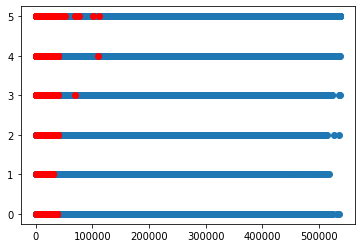

In [19]:
plt.scatter(df1['recipe_id'],df1['rating'])
plt.scatter(anomaly_val['recipe_id'], anomaly_val['rating'], c="r")

      recipe_id  rating
7         51964     5.0
25         1878     0.0
62         8961     0.0
78          100     3.0
84         6812     4.0
...         ...     ...
9931      22941     5.0
9934      19279     5.0
9960      13923     4.0
9979      20935     5.0
9995      23889     5.0

[501 rows x 2 columns]


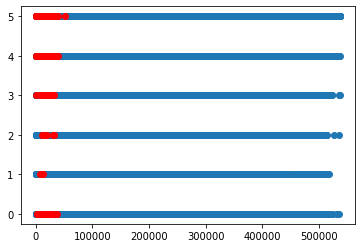

In [21]:
model = OneClassSVM(kernel='linear', gamma=0.001, nu=0.05).fit(df2)
y_pred = model.predict(df2)
y_pred
anomaly_val =df1.iloc[np.where(y_pred == -1)]
print (anomaly_val)
plt.scatter(df1['recipe_id'],df1['rating'])
plt.scatter(anomaly_val['recipe_id'], anomaly_val['rating'], c="r")